In [1]:
!pip install huggingface_hub

In [2]:
import os
import yaml
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm
from huggingface_hub import hf_hub_download

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [3]:
BENCH_DIR = "/home/dnanexus/data_dir/other_benchmarks"
# BENCH_DIR = "/s/project/deeprvat/ukb_gym/other_benchmarks"

# UKBBGym

In [4]:
!mkdir -p {BENCH_DIR}
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated/annotations_fillna_ukbgym.parquet -o {BENCH_DIR}/annotations_fillna_ukbgym.parquet

anno = pl.scan_parquet(f"{BENCH_DIR}/annotations_fillna_ukbgym.parquet")

mac = 20

consequence_columns = [c for c in anno.collect_schema().names() if c.startswith("consequence_")]

anno = (
    anno
    .select(['id', 'region'] + consequence_columns)
    .unpivot(
        index=['id', 'region'],
        on=consequence_columns,
        variable_name='variant_region',
        value_name='value'
    )
    .filter(pl.col('value') == 1)
    .drop('value')
    .collect(engine='streaming')
)
anno

Error: path
"/home/dnanexus/data_dir/other_benchmarks/annotations_fillna_ukbgym.parquet"
already exists but -f/--overwrite was not set


id,region,variant_region
str,str,str
"""chr2:26136528:A:G""","""ENSG00000084733""","""consequence_3_prime_utr_varian…"
"""chr10:17910841:C:A""","""ENSG00000260314""","""consequence_3_prime_utr_varian…"
"""chr8:9137761:G:C""","""ENSG00000173281""","""consequence_3_prime_utr_varian…"
"""chr4:46923927:C:T""","""ENSG00000109158""","""consequence_3_prime_utr_varian…"
"""chr10:96593931:G:T""","""ENSG00000155629""","""consequence_3_prime_utr_varian…"
…,…,…
"""chr3:155020694:G:A""","""ENSG00000196549""","""consequence_upstream_gene_vari…"
"""chr3:121663275:C:G""","""ENSG00000180353""","""consequence_upstream_gene_vari…"
"""chr7:93920088:CAAAAAAAA:C""","""ENSG00000127920""","""consequence_upstream_gene_vari…"


## UKBBGmm phenos

In [5]:
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet -o /home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet

appv = pl.scan_parquet("/home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value_ptile', 'n_individuals']
    )
)

Error: path "/home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrela
ted_appv_percentiles.parquet" already exists but -f/--overwrite was not set


In [6]:
# Get gene trait associations
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet -o /home/dnanexus/data_dir/
# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/loftee_mac20_associations_bh_corrected.parquet -o /home/dnanexus/data_dir/

!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet -o /home/dnanexus/data_dir/

gene_trait_df = (
    pl.read_parquet('/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

loftee_corrs = (
    pl.read_parquet('/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path
"/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet"
already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000244734""","""mean_corpuscular_haemoglobin_i…",5.8426e-107,-0.414609,0.414609,-1.0
"""ENSG00000188536""","""mean_corpuscular_haemoglobin_i…",4.2593e-22,-0.366514,0.366514,-1.0
"""ENSG00000101439""","""cystatin_c_int""",9.0570e-172,-0.364046,0.364046,-1.0
"""ENSG00000167941""","""heel_bone_mineral_density_bmd_…",0.004143,0.309961,0.309961,1.0
"""ENSG00000149948""","""standing_height_int""",0.035047,-0.302164,0.302164,-1.0
…,…,…,…,…,…
"""ENSG00000162992""","""glycated_haemoglobin_hba1c_int""",0.000525,0.004895,0.004895,1.0
"""ENSG00000134030""","""leg_fat_percentage_right_int""",0.028495,0.003606,0.003606,1.0
"""ENSG00000114796""","""position_of_pulse_wave_notch_i…",0.03963,-0.003476,0.003476,-1.0


In [7]:
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())

ukbgym_pheno = (
    appv
    .join(
        anno_ids_lazy, 
        on="id", 
        how="semi"
    )
    .join(
        anno.lazy(), 
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor_ptile = pl.when(pl.col('loftee_corr_dir') == -1)
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )
    .with_columns(
        pathogenic = pl.col('mean_pheno_value_dircor_ptile') > 0.9995,
        
        benchmark = pl.lit("UKBBGym phenotypes"),
    )
    .collect(engine='streaming')
)

ukbgym_pheno

id,phenotype,mean_pheno_value_ptile,n_individuals,region,variant_region,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,mean_pheno_value_dircor_ptile,pathogenic,benchmark
str,str,f32,i32,str,str,f64,f64,f64,f64,f32,bool,str
"""chr1:55060523:CT:C""","""apolipoprotein_b_int""",0.032868,5,"""ENSG00000169174""","""consequence_intron_variant""",5.5832e-33,-0.193888,0.193888,-1.0,0.967132,false,"""UKBBGym phenotypes"""
"""chr1:55067454:T:C""","""apolipoprotein_b_int""",0.040419,1,"""ENSG00000169174""","""consequence_downstream_gene_va…",5.5832e-33,-0.193888,0.193888,-1.0,0.959581,false,"""UKBBGym phenotypes"""
"""chr1:55067454:T:C""","""apolipoprotein_b_int""",0.040419,1,"""ENSG00000169174""","""consequence_downstream_gene_va…",5.5832e-33,-0.193888,0.193888,-1.0,0.959581,false,"""UKBBGym phenotypes"""
"""chr1:55068444:G:A""","""apolipoprotein_b_int""",0.011456,1,"""ENSG00000169174""","""consequence_downstream_gene_va…",5.5832e-33,-0.193888,0.193888,-1.0,0.988544,false,"""UKBBGym phenotypes"""
"""chr1:55068444:G:A""","""apolipoprotein_b_int""",0.011456,1,"""ENSG00000169174""","""consequence_downstream_gene_va…",5.5832e-33,-0.193888,0.193888,-1.0,0.988544,false,"""UKBBGym phenotypes"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr11:72224999:C:A""","""whole_body_water_mass_int""",0.004162,1,"""ENSG00000165458""","""consequence_stop_gained""",0.030338,0.127209,0.127209,1.0,0.004162,false,"""UKBBGym phenotypes"""
"""chr11:72242416:C:A""","""whole_body_water_mass_int""",0.001907,6,"""ENSG00000165458""","""consequence_downstream_gene_va…",0.030338,0.127209,0.127209,1.0,0.001907,false,"""UKBBGym phenotypes"""
"""chr11:72238913:C:T""","""whole_body_water_mass_int""",0.001933,16,"""ENSG00000165458""","""consequence_3_prime_utr_varian…",0.030338,0.127209,0.127209,1.0,0.001933,false,"""UKBBGym phenotypes"""


## UKBBGym Olink

In [8]:
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var/olink_protrider_prs_rint_all_genes_EURunrelated_appv_percentiles.parquet -o /home/dnanexus/olink_protrider_prs_rint_all_genes_EURunrelated_appv_percentiles.parquet

olink_appv = (
    pl.scan_parquet("/home/dnanexus/olink_protrider_prs_rint_all_genes_EURunrelated_appv_percentiles.parquet")
    .filter(
        (pl.col('region') + '_olink' == pl.col('phenotype')) &
        (pl.col('n_individuals') <= mac)
    )
    .with_columns(
        mean_pheno_value_rank=pl.col('mean_pheno_value')
            .rank(method="max", descending=True)
            .cast(pl.Float32)
    )
    .with_columns(
        mean_pheno_value_ptile=(
            pl.col('mean_pheno_value_rank') / pl.len()
        ).cast(pl.Float32)
    )
)

olink_appv

Error: path "/home/dnanexus/olink_protrider_prs_rint_all_genes_EURunrelated_ap
pv_percentiles.parquet" already exists but -f/--overwrite was not set


In [9]:
ukbgym_olink = (
    olink_appv
    .join(
        anno.lazy(), 
        on="id", 
        how="inner"
    )
    .with_columns(
        pathogenic = pl.col('mean_pheno_value_ptile') > 0.9995,
        
        benchmark = pl.lit("UKBBGym Olink"),
    )
    
    .collect(engine='streaming')
)

ukbgym_olink

id,region,phenotype,n_individuals,mean_pheno_value,std_pheno_value,mean_pheno_value_rank,mean_pheno_value_ptile,region_right,variant_region,pathogenic,benchmark
str,str,str,i32,f32,f32,f32,f32,str,str,bool,str
"""chr12:54410307:A:G""","""ENSG00000161638""","""ENSG00000161638_olink""",1,-0.959195,null,1.3865658e7,0.877207,"""ENSG00000161638""","""consequence_intron_variant""",false,"""UKBBGym Olink"""
"""chr12:54400381:CCTT:C""","""ENSG00000161638""","""ENSG00000161638_olink""",1,0.109895,null,6.913758e6,0.437397,"""ENSG00000161638""","""consequence_intron_variant""",false,"""UKBBGym Olink"""
"""chr15:68407960:G:A""","""ENSG00000137809""","""ENSG00000137809_olink""",4,0.116904,0.689094,6.853824e6,0.433605,"""ENSG00000137809""","""consequence_intron_variant""",false,"""UKBBGym Olink"""
"""chr15:68408566:G:A""","""ENSG00000137809""","""ENSG00000137809_olink""",1,0.003307,null,7.841066e6,0.496063,"""ENSG00000137809""","""consequence_intron_variant""",false,"""UKBBGym Olink"""
"""chr15:68433957:G:A""","""ENSG00000137809""","""ENSG00000137809_olink""",1,0.06683,null,7.28653e6,0.46098,"""ENSG00000137809""","""consequence_upstream_gene_vari…",false,"""UKBBGym Olink"""
…,…,…,…,…,…,…,…,…,…,…,…
"""chr7:124744738:T:C""","""ENSG00000170775""","""ENSG00000170775_olink""",1,-0.016881,null,8.017773e6,0.507242,"""ENSG00000170775""","""consequence_3_prime_utr_varian…",false,"""UKBBGym Olink"""
"""chr7:124752185:C:A""","""ENSG00000170775""","""ENSG00000170775_olink""",1,1.046147,null,1.608912e6,0.101787,"""ENSG00000170775""","""consequence_intron_variant""",false,"""UKBBGym Olink"""
"""chr8:21807025:C:T""","""ENSG00000168546""","""ENSG00000168546_olink""",1,-1.476022,null,1.5056119e7,0.952521,"""ENSG00000168546""","""consequence_intron_variant""",false,"""UKBBGym Olink"""


# Other Benchmarks

## ClinVar

In [10]:
# Download ClinVar VCF (GRCh38) and its index
!mkdir -p {BENCH_DIR}/clinvar
!wget -nc https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz -O {BENCH_DIR}/clinvar/clinvar.vcf.gz
!wget -nc https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz.tbi -O {BENCH_DIR}/clinvar/clinvar.vcf.gz.tbi

--2026-01-27 09:29:50--  https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.31, 130.14.250.7, 130.14.250.10, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.31|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 186228201 (178M) [application/x-gzip]
Saving to: ‘/home/dnanexus/data_dir/other_benchmarks/clinvar/clinvar.vcf.gz’

/home/dnanexus/data 100%[===================>] 177.60M  25.4MB/s    in 7.0s    

2026-01-27 09:29:58 (25.3 MB/s) - ‘/home/dnanexus/data_dir/other_benchmarks/clinvar/clinvar.vcf.gz’ saved [186228201/186228201]

--2026-01-27 09:29:59--  https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz.tbi
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.31, 130.14.250.7, 130.14.250.10, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.31|:443... connected.
HTTP request sent, awaiting response...

In [11]:
# 1. Create a dummy dataframe with your example string (added CLNSIG for demonstration)
data = {
    "info_col": [
        ".11:g.917887G>T;CLNVC=single_nucleotide_variant;CLNVCSO=SO:0001483;GENEINFO=LINC02593:100130417;MC=SO:0001627|intron_variant;ORIGIN=0",
        "CLNVC=single_nucleotide_variant;CLNSIG=Likely_benign;MC=SO:0001583|missense_variant;ORIGIN=1",
        "CLNVC=deletion;CLNSIG=Pathogenic;MC=SO:0001587|stop_gained;ORIGIN=1"
    ]
}
df = pl.DataFrame(data)

# 2. Extract the fields using Regex
# We create two new columns by parsing the 'info_col'
df.with_columns(
    # Regex explanation for MC: 
    # Look for "MC=", skip characters until pipe "|", capture text until next comma or semicolon
    variant_region = pl.col("info_col").str.extract(r"MC=[^|]+\|([^;,]+)", 1),
    
    # Regex explanation for CLNSIG: 
    # Look for "CLNSIG=", capture everything until the next semicolon
    clinical_significance = pl.col("info_col").str.extract(r"CLNSIG=([^;]+)", 1)
)

info_col,variant_region,clinical_significance
str,str,str
""".11:g.917887G>T;CLNVC=single_n…","""intron_variant""",null
"""CLNVC=single_nucleotide_varian…","""missense_variant""","""Likely_benign"""
"""CLNVC=deletion;CLNSIG=Pathogen…","""stop_gained""","""Pathogenic"""


In [12]:
clinvar = (
    pl.read_csv(f"{BENCH_DIR}/clinvar/clinvar.vcf.gz", comment_prefix="##", separator="\t", ignore_errors=True)
    .with_columns(
        chrom = pl.col("#CHROM").fill_null("NA"),
    
        # Look for "CLNSIG=", capture everything until the next semicolon
        clinical_significance = pl.col("INFO").str.extract(r"CLNSIG=([^;]+)", 1),
    )
    .with_columns(
        id = pl.col("chrom").cast(str) + ":" + pl.col("POS").cast(str) + ":" + pl.col("REF") + ":" + pl.col("ALT"),

        # Look for "MC=", skip characters until pipe "|", capture text until next comma or semicolon
        variant_region = pl.col("INFO").str.extract(r"MC=[^|]+\|([^;,]+)", 1),

        pathogenic = (
            pl.when(pl.col("clinical_significance").is_in(["Pathogenic", "Likely_pathogenic"])).then(1)
            .otherwise(pl.when(pl.col("clinical_significance").is_in(["Benign", "Likely_benign"])).then(0).otherwise(None))
        ),

        benchmark = pl.lit("ClinVar"),
    )
)

clinvar

#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,chrom,clinical_significance,id,variant_region,pathogenic,benchmark
i64,i64,i64,str,str,str,str,str,str,str,str,str,i32,str
1,66926,3385321,"""AG""","""A""",""".""",""".""","""ALLELEID=3544463;CLNDISDB=Huma…","""1""","""Uncertain_significance""","""1:66926:AG:A""","""intron_variant""",null,"""ClinVar"""
1,69134,2205837,"""A""","""G""",""".""",""".""","""ALLELEID=2193183;CLNDISDB=MedG…","""1""","""Likely_benign""","""1:69134:A:G""","""missense_variant""",0,"""ClinVar"""
1,69241,4562067,"""C""","""T""",""".""",""".""","""ALLELEID=4679177;CLNDISDB=MedG…","""1""","""Uncertain_significance""","""1:69241:C:T""","""missense_variant""",null,"""ClinVar"""
1,69308,3925305,"""A""","""G""",""".""",""".""","""ALLELEID=4039319;CLNDISDB=MedG…","""1""","""Uncertain_significance""","""1:69308:A:G""","""missense_variant""",null,"""ClinVar"""
1,69314,3205580,"""T""","""G""",""".""",""".""","""ALLELEID=3374047;CLNDISDB=MedG…","""1""","""Uncertain_significance""","""1:69314:T:G""","""missense_variant""",null,"""ClinVar"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…
null,274185,3778023,"""C""","""T""",""".""",""".""","""ALLELEID=3894028;CLNDISDB=MedG…","""NA""","""Likely_benign""","""NA:274185:C:T""","""intron_variant""",0,"""ClinVar"""
null,274366,2206666,"""G""","""C""",""".""",""".""","""ALLELEID=2200058;CLNDISDB=MedG…","""NA""","""Uncertain_significance""","""NA:274366:G:C""","""missense_variant""",null,"""ClinVar"""
null,275068,2241971,"""T""","""C""",""".""",""".""","""ALLELEID=2226217;CLNDISDB=MedG…","""NA""","""Uncertain_significance""","""NA:275068:T:C""","""missense_variant""",null,"""ClinVar"""


## TraitGym

In [13]:
# Download the file to your local cache and get the path
file_path = hf_hub_download(
    repo_id="songlab/TraitGym", 
    filename="mendelian_traits_matched_9/test.parquet",
    repo_type="dataset"
)

# 1. Define the mapping dictionary
ccre_to_vep = {
    # Promoters
    "PLS": "promoter_variant",
    "PLS_flank": "promoter_variant",
    
    # Enhancers (Proximal and Distal)
    "pELS": "enhancer_variant",
    "pELS_flank": "regulatory_region_variant",
    "dELS": "enhancer_variant",
    "dELS_flank": "regulatory_region_variant", # Generic regulatory term for flanking regions
    
    # Transcription Factors
    "CTCF-only": "TF_binding_site_variant",
    "CTCF-only_flank": "regulatory_region_variant",
    
    # Ambiguous / Poised regions
    "DNase-H3K4me3": "regulatory_region_variant",
    "DNase-H3K4me3_flank": "regulatory_region_variant" 
}


# Read the local file
trait_gym_m = (
    pl.read_parquet(file_path)
    .with_columns(
        id = pl.concat_str([
            pl.col("chrom").cast(pl.Utf8),
            pl.lit(":"),
            pl.col("pos").cast(pl.Utf8),
            pl.lit(":"),
            pl.col("ref"),
            pl.lit(":"),
            pl.col("alt")
        ]),
        variant_region = (
            pl.when(pl.col("consequence").is_in(ccre_to_vep.keys()))
            .then(pl.col("consequence").replace(ccre_to_vep, default=None))
            .otherwise(pl.col("consequence"))
        ),
        pathogenic = pl.col('label'),
        benchmark = pl.lit("TraitGym mendelian traits (matched)")
    )
)
trait_gym_m

mendelian_traits_matched_9/test.parquet:   0%|          | 0.00/50.2k [00:00<?, ?B/s]

/tmp/ipykernel_65147/1237399667.py:45: DeprecationWarning: the `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
(Deprecated in version 1.0.0)


chrom,pos,ref,alt,OMIM,consequence,label,tss_dist,match_group,id,variant_region,pathogenic,benchmark
str,i64,str,str,str,str,bool,i64,str,str,str,bool,str
"""1""",1425822,"""C""","""G""",null,"""PLS""",false,48,"""PLS_4""","""1:1425822:C:G""","""promoter_variant""",false,"""TraitGym mendelian traits (mat…"
"""1""",1615869,"""C""","""T""",null,"""PLS""",false,35,"""PLS_0""","""1:1615869:C:T""","""promoter_variant""",false,"""TraitGym mendelian traits (mat…"
"""1""",1659060,"""G""","""A""",null,"""PLS""",false,47,"""PLS_4""","""1:1659060:G:A""","""promoter_variant""",false,"""TraitGym mendelian traits (mat…"
"""1""",1659114,"""A""","""G""",null,"""PLS""",false,101,"""PLS_5""","""1:1659114:A:G""","""promoter_variant""",false,"""TraitGym mendelian traits (mat…"
"""1""",2050958,"""T""","""C""",null,"""5_prime_UTR_variant""",false,149,"""5_prime_UTR_variant_7""","""1:2050958:T:C""","""5_prime_UTR_variant""",false,"""TraitGym mendelian traits (mat…"
…,…,…,…,…,…,…,…,…,…,…,…,…
"""X""",155613005,"""C""","""T""",null,"""PLS""",false,52,"""PLS_52""","""X:155613005:C:T""","""promoter_variant""",false,"""TraitGym mendelian traits (mat…"
"""X""",155719093,"""C""","""A""",null,"""5_prime_UTR_variant""",false,4,"""5_prime_UTR_variant_101""","""X:155719093:C:A""","""5_prime_UTR_variant""",false,"""TraitGym mendelian traits (mat…"
"""X""",155881342,"""A""","""C""",null,"""PLS""",false,2,"""PLS_57""","""X:155881342:A:C""","""promoter_variant""",false,"""TraitGym mendelian traits (mat…"


In [14]:
trait_gym_m['variant_region'].unique()

variant_region
str
"""non_coding_transcript_exon_var…"
"""intergenic_variant"""
"""intron_variant"""
"""regulatory_region_variant"""
"""3_prime_UTR_variant"""
"""5_prime_UTR_variant"""
"""enhancer_variant"""
"""promoter_variant"""
"""upstream_gene_variant"""


In [15]:
# Download the file to your local cache and get the path
file_path = hf_hub_download(
    repo_id="songlab/TraitGym", 
    filename="complex_traits_matched_9/test.parquet",
    repo_type="dataset"
)

# Read the local file
trait_gym_c = (
    pl.read_parquet(file_path)
    .with_columns(
        id = pl.concat_str([
            pl.col("chrom").cast(pl.Utf8),
            pl.lit(":"),
            pl.col("pos").cast(pl.Utf8),
            pl.lit(":"),
            pl.col("ref"),
            pl.lit(":"),
            pl.col("alt")
        ]),
        variant_region = (
            pl.when(pl.col("consequence").is_in(ccre_to_vep.keys()))
            .then(pl.col("consequence").replace(ccre_to_vep, default=None))
            .otherwise(pl.col("consequence"))
        ),
        pathogenic = pl.col('label'),
        benchmark = pl.lit("TraitGym mendelian traits (matched)")
    )
)
trait_gym_c

complex_traits_matched_9/test.parquet:   0%|          | 0.00/411k [00:00<?, ?B/s]

/tmp/ipykernel_65147/3739900729.py:23: DeprecationWarning: the `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
(Deprecated in version 1.0.0)


chrom,pos,ref,alt,pip,trait,label,maf,ld_score,consequence,tss_dist,match_group,id,variant_region,pathogenic,benchmark
str,i64,str,str,f64,str,bool,f64,f64,str,i64,str,str,str,bool,str
"""1""",867476,"""C""","""T""",0.00156,"""""",false,0.079465,44.053,"""non_coding_transcript_exon_var…",56446,"""non_coding_transcript_exon_var…","""1:867476:C:T""","""non_coding_transcript_exon_var…",false,"""TraitGym mendelian traits (mat…"
"""1""",868052,"""T""","""C""",0.001791,"""""",false,0.077747,44.057,"""non_coding_transcript_exon_var…",55870,"""non_coding_transcript_exon_var…","""1:868052:T:C""","""non_coding_transcript_exon_var…",false,"""TraitGym mendelian traits (mat…"
"""1""",868635,"""A""","""G""",0.004349,"""""",false,0.075255,43.639,"""non_coding_transcript_exon_var…",55287,"""non_coding_transcript_exon_var…","""1:868635:A:G""","""non_coding_transcript_exon_var…",false,"""TraitGym mendelian traits (mat…"
"""1""",870176,"""T""","""A""",0.0,"""""",false,0.084371,37.271,"""non_coding_transcript_exon_var…",53746,"""non_coding_transcript_exon_var…","""1:870176:T:A""","""non_coding_transcript_exon_var…",false,"""TraitGym mendelian traits (mat…"
"""1""",1052930,"""A""","""G""",0.001467,"""""",false,0.058385,46.907,"""non_coding_transcript_exon_var…",18823,"""non_coding_transcript_exon_var…","""1:1052930:A:G""","""non_coding_transcript_exon_var…",false,"""TraitGym mendelian traits (mat…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""22""",50368376,"""T""","""C""",0.0,"""""",false,0.19181,86.507,"""dELS""",3695,"""dELS_204""","""22:50368376:T:C""","""enhancer_variant""",false,"""TraitGym mendelian traits (mat…"
"""22""",50571623,"""C""","""T""",0.0,"""""",false,0.061159,23.9,"""dELS""",6291,"""dELS_202""","""22:50571623:C:T""","""enhancer_variant""",false,"""TraitGym mendelian traits (mat…"
"""22""",50671289,"""G""","""A""",0.0,"""""",false,0.036223,12.733,"""pELS_flank""",3125,"""pELS_flank_26""","""22:50671289:G:A""","""regulatory_region_variant""",false,"""TraitGym mendelian traits (mat…"


## ProteinGym

In [16]:
VERSION = "v1.3"
FILENAME = "DMS_ProteinGym_substitutions.zip"
TARGET_DIR = f"{BENCH_DIR}/protein_gym"
TARGET_FILE = f"{TARGET_DIR}/{FILENAME}"

# 1. Create Directory
!mkdir -p {TARGET_DIR}

# 2. Download only if missing
if not os.path.exists(TARGET_FILE):
    print("File not found. Downloading...")
    !curl -o {TARGET_FILE} https://marks.hms.harvard.edu/proteingym/ProteinGym_{VERSION}/{FILENAME}
else:
    print("File already exists. Skipping download.")

# 3. Unzip with "Yes to All" (-o)
# We use -o to overwrite if it exists, avoiding the interactive prompt
print("Unzipping...")
!unzip -o {TARGET_FILE} -d {TARGET_DIR}

File not found. Downloading...
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 41.0M  100 41.0M    0     0  26.0M      0  0:00:01  0:00:01 --:--:-- 26.0M
Unzipping...
Archive:  /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_substitutions.zip
   creating: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_substitutions/
  inflating: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_substitutions/SDA_BACSU_Tsuboyama_2023_1PV0.csv  
  inflating: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_substitutions/PAI1_HUMAN_Huttinger_2021.csv  
  inflating: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_substitutions/S22A1_HUMAN_Yee_2023_activity.csv  
  inflating: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_substitutions/HIS7_YEAST_Pokusaeva_2019.csv  
  inflating

In [17]:
VERSION = "v1.3"
FILENAME = "DMS_ProteinGym_indels.zip"
TARGET_DIR = f"{BENCH_DIR}/protein_gym"
TARGET_FILE = f"{TARGET_DIR}/{FILENAME}"

# 1. Create Directory
!mkdir -p {TARGET_DIR}

# 2. Download only if missing
if not os.path.exists(TARGET_FILE):
    print("File not found. Downloading...")
    !curl -o {TARGET_FILE} https://marks.hms.harvard.edu/proteingym/ProteinGym_{VERSION}/{FILENAME}
else:
    print("File already exists. Skipping download.")

# 3. Unzip with "Yes to All" (-o)
# We use -o to overwrite if it exists, avoiding the interactive prompt
print("Unzipping...")
!unzip -o {TARGET_FILE} -d {TARGET_DIR}

File not found. Downloading...
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 6552k  100 6552k    0     0  7408k      0 --:--:-- --:--:-- --:--:-- 7403k
Unzipping...
Archive:  /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_indels.zip
   creating: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_indels/
  inflating: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_indels/SDA_BACSU_Tsuboyama_2023_1PV0_indels.csv  
  inflating: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_indels/PR40A_HUMAN_Tsuboyama_2023_1UZC_indels.csv  
  inflating: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_indels/BBC1_YEAST_Tsuboyama_2023_1TG0_indels.csv  
  inflating: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_indels/MBD11_ARATH_Tsuboyama_2023_6ACV_indels.csv  
  inflating:

In [18]:
# csv_pattern = f"{TARGET_DIR}/**/*HUMAN*.csv"
csv_pattern = f"{TARGET_DIR}/DMS_ProteinGym_substitutions/*HUMAN*.csv"

print(f"Scanning files matching: {csv_pattern}")

# 2. Scan and Compile
# 'include_file_paths' creates a column with the file path, which is 
# critical to distinguish which assay the variants come from.
proteingym_snp = (
    pl.scan_csv(csv_pattern, include_file_paths="source_file")
    .with_columns(
        # Extract just the assay name (remove path and extension)
        assay_id = pl.col("source_file")
                    .str.split("/")
                    .list.last()
                    .str.strip_suffix(".csv")
    )
    .collect()

    .with_columns(
        # 1. Flag Bottom 1%
        is_bottom_1pct = pl.col("DMS_score") <= pl.col("DMS_score").quantile(0.01).over("assay_id"),
        
        # 2. Flag Top 1%
        is_top_1pct = pl.col("DMS_score") >= pl.col("DMS_score").quantile(0.99).over("assay_id")
    )
    .with_columns(
        id = pl.col('mutant'),
        variant_region = pl.lit("missense_variant"),
        pathogenic = pl.col("is_bottom_1pct") | pl.col("is_top_1pct"),
        benchmark = pl.lit("ProteinGym SNP (Human)"),
    )
)

proteingym_snp

Scanning files matching: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_substitutions/*HUMAN*.csv


mutant,mutated_sequence,DMS_score,DMS_score_bin,source_file,assay_id,is_bottom_1pct,is_top_1pct,id,variant_region,pathogenic,benchmark
str,str,f64,i64,str,str,bool,bool,str,str,bool,str
"""A673C""","""MLPGLALLLLAAWTARALEVPTDGNAGLLA…",-1.018869,1,"""/home/dnanexus/data_dir/other_…","""A4_HUMAN_Seuma_2022""",false,false,"""A673C""","""missense_variant""",false,"""ProteinGym SNP (Human)"""
"""A673D""","""MLPGLALLLLAAWTARALEVPTDGNAGLLA…",-0.605052,1,"""/home/dnanexus/data_dir/other_…","""A4_HUMAN_Seuma_2022""",false,false,"""A673D""","""missense_variant""",false,"""ProteinGym SNP (Human)"""
"""A673E""","""MLPGLALLLLAAWTARALEVPTDGNAGLLA…",-0.590857,1,"""/home/dnanexus/data_dir/other_…","""A4_HUMAN_Seuma_2022""",false,false,"""A673E""","""missense_variant""",false,"""ProteinGym SNP (Human)"""
"""A673E:A692E""","""MLPGLALLLLAAWTARALEVPTDGNAGLLA…",-2.443601,0,"""/home/dnanexus/data_dir/other_…","""A4_HUMAN_Seuma_2022""",false,false,"""A673E:A692E""","""missense_variant""",false,"""ProteinGym SNP (Human)"""
"""A673E:A692T""","""MLPGLALLLLAAWTARALEVPTDGNAGLLA…",-3.049893,0,"""/home/dnanexus/data_dir/other_…","""A4_HUMAN_Seuma_2022""",false,false,"""A673E:A692T""","""missense_variant""",false,"""ProteinGym SNP (Human)"""
…,…,…,…,…,…,…,…,…,…,…,…
"""R203H""","""MDPGQQPPPQPAPQGQGQPPSQPPQGQGPP…",0.124027,0,"""/home/dnanexus/data_dir/other_…","""YAP1_HUMAN_Araya_2012""",false,false,"""R203H""","""missense_variant""",false,"""ProteinGym SNP (Human)"""
"""R203G""","""MDPGQQPPPQPAPQGQGQPPSQPPQGQGPP…",0.150523,0,"""/home/dnanexus/data_dir/other_…","""YAP1_HUMAN_Araya_2012""",false,false,"""R203G""","""missense_variant""",false,"""ProteinGym SNP (Human)"""
"""R203D""","""MDPGQQPPPQPAPQGQGQPPSQPPQGQGPP…",0.138661,0,"""/home/dnanexus/data_dir/other_…","""YAP1_HUMAN_Araya_2012""",false,false,"""R203D""","""missense_variant""",false,"""ProteinGym SNP (Human)"""


In [19]:
# csv_pattern = f"{TARGET_DIR}/**/*HUMAN*.csv"
csv_pattern = f"{TARGET_DIR}/DMS_ProteinGym_indels/*HUMAN*.csv"

print(f"Scanning files matching: {csv_pattern}")

# 2. Scan and Compile
# 'include_file_paths' creates a column with the file path, which is 
# critical to distinguish which assay the variants come from.
proteingym_indel = (
    pl.scan_csv(csv_pattern, include_file_paths="source_file")
    .with_columns(
        # Extract just the assay name (remove path and extension)
        assay_id = pl.col("source_file")
                    .str.split("/")
                    .list.last()
                    .str.strip_suffix(".csv")
    )
    .collect()

    .with_columns(
        # 1. Flag Bottom 1%
        is_bottom_1pct = pl.col("DMS_score") <= pl.col("DMS_score").quantile(0.01).over("assay_id"),
        
        # 2. Flag Top 1%
        is_top_1pct = pl.col("DMS_score") >= pl.col("DMS_score").quantile(0.99).over("assay_id")
    )
    .with_columns(
        id = pl.col('mutated_sequence'),
        variant_region = pl.lit("frameshift_variant"),
        pathogenic = pl.col("is_bottom_1pct") | pl.col("is_top_1pct"),
        benchmark = pl.lit("ProteinGym indel (Human)")
    )
)

proteingym_indel

Scanning files matching: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_indels/*HUMAN*.csv


mutated_sequence,DMS_score,DMS_score_bin,source_file,assay_id,is_bottom_1pct,is_top_1pct,id,variant_region,pathogenic,benchmark
str,f64,i64,str,str,bool,bool,str,str,bool,str
"""MLPGLALLLLAAWTARALEVPTDGNAGLLA…",-3.311444,0,"""/home/dnanexus/data_dir/other_…","""A4_HUMAN_Seuma_2022_indels""",false,false,"""MLPGLALLLLAAWTARALEVPTDGNAGLLA…","""frameshift_variant""",false,"""ProteinGym indel (Human)"""
"""MLPGLALLLLAAWTARALEVPTDGNAGLLA…",-3.36364,0,"""/home/dnanexus/data_dir/other_…","""A4_HUMAN_Seuma_2022_indels""",false,false,"""MLPGLALLLLAAWTARALEVPTDGNAGLLA…","""frameshift_variant""",false,"""ProteinGym indel (Human)"""
"""MLPGLALLLLAAWTARALEVPTDGNAGLLA…",-3.413797,0,"""/home/dnanexus/data_dir/other_…","""A4_HUMAN_Seuma_2022_indels""",false,false,"""MLPGLALLLLAAWTARALEVPTDGNAGLLA…","""frameshift_variant""",false,"""ProteinGym indel (Human)"""
"""MLPGLALLLLAAWTARALEVPTDGNAGLLA…",-3.352993,0,"""/home/dnanexus/data_dir/other_…","""A4_HUMAN_Seuma_2022_indels""",false,false,"""MLPGLALLLLAAWTARALEVPTDGNAGLLA…","""frameshift_variant""",false,"""ProteinGym indel (Human)"""
"""MLPGLALLLLAAWTARALEVPTDGNAGLLA…",0.235065,1,"""/home/dnanexus/data_dir/other_…","""A4_HUMAN_Seuma_2022_indels""",false,false,"""MLPGLALLLLAAWTARALEVPTDGNAGLLA…","""frameshift_variant""",false,"""ProteinGym indel (Human)"""
…,…,…,…,…,…,…,…,…,…,…
"""HRQALGGERLYPRVQAMQPAFASKITGMLL…",-1.300614,0,"""/home/dnanexus/data_dir/other_…","""UBR5_HUMAN_Tsuboyama_2023_1I2T…",false,false,"""HRQALGGERLYPRVQAMQPAFASKITGMLL…","""frameshift_variant""",false,"""ProteinGym indel (Human)"""
"""HRQALGRLYPRVQAMQPAFASKITGMLLEL…",-0.619357,0,"""/home/dnanexus/data_dir/other_…","""UBR5_HUMAN_Tsuboyama_2023_1I2T…",false,false,"""HRQALGRLYPRVQAMQPAFASKITGMLLEL…","""frameshift_variant""",false,"""ProteinGym indel (Human)"""
"""HRQGALGERLYPRVQAMQPAFASKITGMLL…",-0.421069,1,"""/home/dnanexus/data_dir/other_…","""UBR5_HUMAN_Tsuboyama_2023_1I2T…",false,false,"""HRQGALGERLYPRVQAMQPAFASKITGMLL…","""frameshift_variant""",false,"""ProteinGym indel (Human)"""


## GeneticGym

In [46]:
!mkdir -p {BENCH_DIR}/genetics_gym
!wget -nc https://storage.googleapis.com/genetics-gym/evaluation_tables/dd-with-combined-controls.tsv.bgz -O {BENCH_DIR}/genetics_gym/dd-with-combined-controls.tsv.bgz
!wget -nc https://storage.googleapis.com/genetics-gym/evaluation_tables/asd-with-combined-controls.tsv.bgz -O {BENCH_DIR}/genetics_gym/asd-with-combined-controls.tsv.bgz
!wget -nc https://storage.googleapis.com/genetics-gym/evaluation_tables/chd-with-combined-controls.tsv.bgz -O {BENCH_DIR}/genetics_gym/chd-with-combined-controls.tsv.bgz

!wget -nc https://storage.googleapis.com/genetics-gym/evaluation_tables/schema_evaluation_table.tsv.bgz -O {BENCH_DIR}/genetics_gym/schema_evaluation_table.tsv.bgz
!wget -nc https://storage.googleapis.com/genetics-gym/evaluation_tables/asc_evaluation_table.tsv.bgz -O {BENCH_DIR}/genetics_gym/asc_evaluation_table.tsv.bgz
!wget -nc https://storage.googleapis.com/genetics-gym/evaluation_tables/epi25_evaluation_table.tsv.bgz -O {BENCH_DIR}/genetics_gym/epi25_evaluation_table.tsv.bgz


!wget -nc https://storage.googleapis.com/genetics-gym/evaluation_tables/genebass_evaluation_table.tsv.bgz -O {BENCH_DIR}/genetics_gym/genebass_evaluation_table.tsv.bgz
!wget -nc https://storage.googleapis.com/genetics-gym/evaluation_tables/gnomad-independent-set.tsv.bgz -O {BENCH_DIR}/genetics_gym/gnomad-independent-set.tsv.bgz

File ‘/s/project/deeprvat/ukb_gym/other_benchmarks/genetics_gym/dd-with-combined-controls.tsv.bgz’ already there; not retrieving.
--2026-01-26 18:35:57--  https://storage.googleapis.com/genetics-gym/evaluation_tables/asd-with-combined-controls.tsv.bgz
Resolving storage.googleapis.com (storage.googleapis.com)... 2a00:1450:4001:804::201b, 2a00:1450:4001:80d::201b, 2a00:1450:4001:831::201b, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|2a00:1450:4001:804::201b|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 95112 (93K) [application/octet-stream]
Saving to: ‘/s/project/deeprvat/ukb_gym/other_benchmarks/genetics_gym/asd-with-combined-controls.tsv.bgz’

/s/project/deeprvat 100%[===================>]  92.88K   580KB/s    in 0.2s    

2026-01-26 18:35:58 (580 KB/s) - ‘/s/project/deeprvat/ukb_gym/other_benchmarks/genetics_gym/asd-with-combined-controls.tsv.bgz’ saved [95112/95112]

--2026-01-26 18:35:58--  https://storage.googleapis.com/genetics-gym

In [44]:
geneticsgym_ddd = (
    pl.read_csv(f"{BENCH_DIR}/genetics_gym/dd-with-combined-controls.tsv.bgz", separator="\t")
    
)
geneticsgym_ddd

chrom,pos,ref,alt,is_pos_dd
str,i64,str,str,bool
"""chr1""",935836,"""G""","""A""",true
"""chr1""",942482,"""T""","""C""",true
"""chr1""",942642,"""G""","""A""",true
"""chr1""",945120,"""G""","""C""",true
"""chr1""",948519,"""T""","""C""",true
…,…,…,…,…
"""chrX""",154773227,"""G""","""A""",true
"""chrX""",154776317,"""G""","""A""",true
"""chrX""",154906457,"""C""","""T""",false


In [47]:
geneticsgym = pl.read_csv(f"{BENCH_DIR}/genetics_gym/gnomad-independent-set.tsv.bgz", separator="\t")
geneticsgym

chrom,pos,ref,alt,is_pos
str,i64,str,str,bool
"""chr1""",65431,"""C""","""A""",true
"""chr1""",65431,"""C""","""G""",true
"""chr1""",65431,"""C""","""T""",true
"""chr1""",65432,"""A""","""C""",true
"""chr1""",65432,"""A""","""G""",true
…,…,…,…,…
"""chrX""",156010408,"""A""","""C""",true
"""chrX""",156010408,"""A""","""G""",true
"""chrX""",156010408,"""A""","""T""",true


[===========================================================>] Uploaded 251,269,516 of 251,269,516 bytes (100%) /home/dnanexus/data_dir/other_benchmarks/comparison_of_benchmarks.parquet
ID                                file-J5qx9Q0Jg0y9YjXjBg8Qb8g2
Class                             file
Project                           project-Gyp4fvjJg0yFZ374KvP9bGFJ
Folder                            /processed_data/ukbgym
Name                              comparison_of_benchmarks.parquet
State                             closing
Visibility                        visible
Types                             -
Properties                        -
Tags                              -
Outgoing links                    -
Created                           Mon Jan 26 20:55:28 2026
Created by                        shubhankar
 via the job                      job-J5qkPFQJg0y5kXFbf2zY6qFk
Last modified                     Mon Jan 26 20:55:30 2026
Media type                        
archivalState                  

id,variant_region,pathogenic,benchmark
str,str,i32,str
"""chr20:9456281:A:G""","""consequence_intron_variant""",0,"""UKBBGym phenotypes"""
"""chr20:9179107:T:A""","""consequence_intron_variant""",0,"""UKBBGym phenotypes"""
"""chr20:9087655:C:T""","""consequence_intron_variant""",0,"""UKBBGym phenotypes"""
"""chr20:9086882:C:G""","""consequence_intron_variant""",0,"""UKBBGym phenotypes"""
"""chr20:9086981:A:C""","""consequence_intron_variant""",0,"""UKBBGym phenotypes"""
…,…,…,…
"""HRQALGGERLYPRVQAMQPAFASKITGMLL…","""frameshift_variant""",0,"""ProteinGym indel (Human)"""
"""HRQALGRLYPRVQAMQPAFASKITGMLLEL…","""frameshift_variant""",0,"""ProteinGym indel (Human)"""
"""HRQGALGERLYPRVQAMQPAFASKITGMLL…","""frameshift_variant""",0,"""ProteinGym indel (Human)"""


# Plotting

In [21]:
import os
import yaml
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [23]:
consequence_map = {
    # --- CDS (Coding Sequence) ---
    'consequence_missense_variant': 'CDS',
    'missense_variant': 'CDS',
    'consequence_frameshift_variant': 'CDS',
    'frameshift_variant': 'CDS',
    'consequence_synonymous_variant': 'CDS',
    'synonymous_variant': 'CDS',
    'consequence_stop_gained': 'CDS',
    'nonsense': 'CDS',
    'consequence_stop_lost': 'CDS',
    'stop_lost': 'CDS',
    'consequence_start_lost': 'CDS',
    'consequence_start_retained_variant': 'CDS',
    'consequence_stop_retained_variant': 'CDS',
    'consequence_incomplete_terminal_codon_variant': 'CDS',
    'initiator_codon_variant': 'CDS',
    'consequence_coding_sequence_variant': 'CDS',
    'consequence_protein_altering_variant': 'CDS',
    'inframe_deletion': 'CDS',
    'consequence_inframe_deletion': 'CDS',
    'inframe_insertion': 'CDS',
    'consequence_inframe_insertion': 'CDS',
    'inframe_indel': 'CDS',

    # --- Splicing ---
    'consequence_splice_donor_variant': 'Splicing',
    'splice_donor_variant': 'Splicing',
    'consequence_splice_acceptor_variant': 'Splicing',
    'splice_acceptor_variant': 'Splicing',
    'consequence_splice_region_variant': 'Splicing',
    'consequence_splice_donor_5th_base_variant': 'Splicing',
    'consequence_splice_donor_region_variant': 'Splicing',
    'consequence_splice_polypyrimidine_tract_variant': 'Splicing',

    # --- UTR (Untranslated Regions) ---
    'consequence_3_prime_utr_variant': 'UTR',
    '3_prime_UTR_variant': 'UTR',
    'consequence_5_prime_utr_variant': 'UTR',
    '5_prime_UTR_variant': 'UTR',

    # --- Promoter (TSS & Upstream) ---
    'promoter_variant': 'Promoter',
    'upstream_gene_variant': 'Promoter',
    'consequence_upstream_gene_variant': 'Promoter',
    'genic_upstream_transcript_variant': 'Promoter',

    # --- Introns (and Non-coding exons) ---
    'intron_variant': 'Introns',
    'consequence_intron_variant': 'Introns',
    'non_coding_transcript_exon_variant': 'Introns', 
    'non-coding_transcript_variant': 'Introns',

    # --- Intergenic (Distal, Downstream, & Regulatory) ---
    'intergenic_variant': 'Intergenic',
    'downstream_gene_variant': 'Intergenic',
    'consequence_downstream_gene_variant': 'Intergenic',
    'genic_downstream_transcript_variant': 'Intergenic',
    'regulatory_region_variant': 'Intergenic',
    'enhancer_variant': 'Intergenic',
    'TF_binding_site_variant': 'Intergenic',
    'no_sequence_alteration': 'Intergenic'
}



# Pathogenicity across regions UKBB

In [24]:
ukbgym_patho = (
    ukbgym_pheno
    .with_columns(
        broad_consequence = pl.col("variant_region").replace(consequence_map, default="Other")
    )
    .drop_nulls()
    .group_by('broad_consequence', 'benchmark')
    .agg(
        n_vars = pl.len(),
        n_patho = pl.col('pathogenic').sum().cast(pl.Int32),
    )
    .with_columns(
        frac_patho = pl.col('n_patho') / pl.col('n_vars')
    )
)

ukbgym_patho

/tmp/ipykernel_65147/2084584519.py:4: DeprecationWarning: the `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
(Deprecated in version 1.0.0)


broad_consequence,benchmark,n_vars,n_patho,frac_patho
str,str,u64,i32,f64
"""Splicing""","""UKBBGym phenotypes""",126426,2700,0.021356
"""Promoter""","""UKBBGym phenotypes""",1279646,25729,0.020106
"""CDS""","""UKBBGym phenotypes""",743772,13889,0.018674
"""Introns""","""UKBBGym phenotypes""",23377846,193694,0.008285
"""UTR""","""UKBBGym phenotypes""",553431,10128,0.0183
"""Intergenic""","""UKBBGym phenotypes""",1714244,24227,0.014133


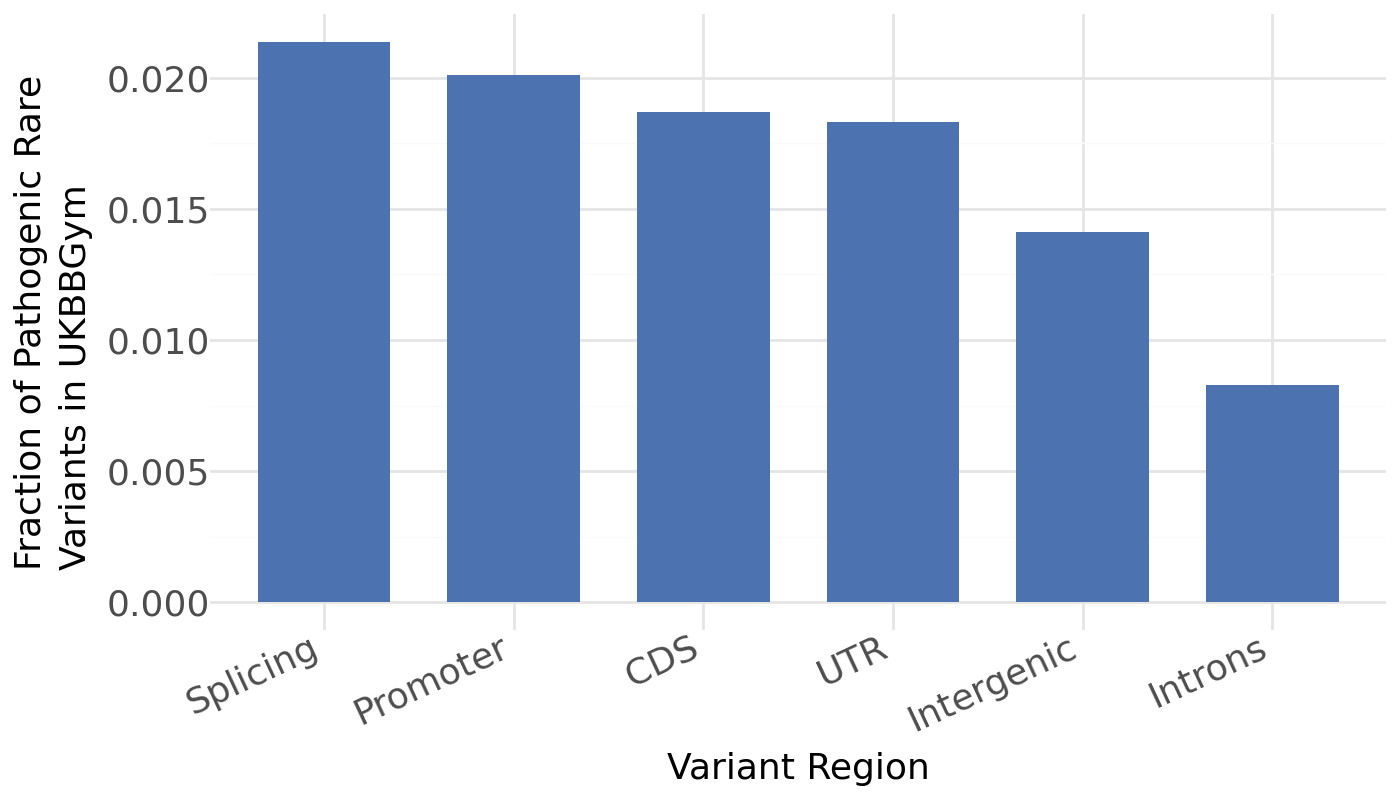

In [28]:
PLOT_TYPE = "fraction" 

if PLOT_TYPE == "fraction":
    y_col = "frac_patho"
    y_label = "Fraction of Pathogenic Rare\nVariants in UKBBGym"
else:
    y_col = "n_patho"
    y_label = "Pathogenic Rare\nVariants in UKBBGym"

# --- Plotting ---
(
    ggplot(ukbgym_patho)
    + geom_bar(
        aes(
            # Sort x-axis by the y-value in descending order using reorder(cat, -val)
            x=f"reorder(broad_consequence, -{y_col})", 
            y=y_col
        ),
        stat="identity",
        position="dodge",
        fill="#4C72B0",
        width=0.7,
    )
    + labs(
        x="Variant Region",
        y=y_label,
    )
    + theme_minimal()
    + theme(
        figure_size=(7, 4),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        axis_text_x=element_text(rotation=25, hjust=1), 
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        legend_position=(0.9, 0.9), 
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)

## Across benchmark plots

In [ ]:
common_cols = ['id', 'variant_region', 'pathogenic', 'benchmark']

oth_bmrk = pl.concat([
        ukbgym_pheno.select(common_cols),
        ukbgym_olink.select(common_cols),
        clinvar.select(common_cols), #.drop_nulls(subset=['pathogenic']),
        trait_gym_m.select(common_cols),
        trait_gym_c.select(common_cols),
        proteingym_snp.select(common_cols),
        proteingym_indel.select(common_cols),
    ],
    how="vertical_relaxed"
)

oth_bmrk.write_parquet(f"{BENCH_DIR}/comparison_of_benchmarks.parquet")
# !dx upload {BENCH_DIR}/comparison_of_benchmarks.parquet --path project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/

oth_bmrk

id,variant_region,pathogenic,benchmark
str,str,i32,str
"""chr1:55060523:CT:C""","""consequence_intron_variant""",0,"""UKBBGym phenotypes"""
"""chr1:55067454:T:C""","""consequence_downstream_gene_va…",0,"""UKBBGym phenotypes"""
"""chr1:55067454:T:C""","""consequence_downstream_gene_va…",0,"""UKBBGym phenotypes"""
"""chr1:55068444:G:A""","""consequence_downstream_gene_va…",0,"""UKBBGym phenotypes"""
"""chr1:55068444:G:A""","""consequence_downstream_gene_va…",0,"""UKBBGym phenotypes"""
…,…,…,…
"""HRQALGGERLYPRVQAMQPAFASKITGMLL…","""frameshift_variant""",0,"""ProteinGym indel (Human)"""
"""HRQALGRLYPRVQAMQPAFASKITGMLLEL…","""frameshift_variant""",0,"""ProteinGym indel (Human)"""
"""HRQGALGERLYPRVQAMQPAFASKITGMLL…","""frameshift_variant""",0,"""ProteinGym indel (Human)"""


In [36]:
!dx upload {BENCH_DIR}/comparison_of_benchmarks.parquet --path project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/

[===========================================================>] Uploaded 279,744,086 of 279,744,086 bytes (100%) /home/dnanexus/data_dir/other_benchmarks/comparison_of_benchmarks.parquet
ID                                file-J5v8Y2QJg0yG8Yg3qkBqP1ZF
Class                             file
Project                           project-Gyp4fvjJg0yFZ374KvP9bGFJ
Folder                            /processed_data/ukbgym
Name                              comparison_of_benchmarks.parquet
State                             closing
Visibility                        visible
Types                             -
Properties                        -
Tags                              -
Outgoing links                    -
Created                           Tue Jan 27 09:46:50 2026
Created by                        shubhankar
 via the job                      job-J5v79yjJg0yBj3Kv7KzX13zZ
Last modified                     Tue Jan 27 09:46:52 2026
Media type                        
archivalState                  

In [ ]:
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/comparison_of_benchmarks.parquet -o /home/dnanexus/data_dir/comparison_of_benchmarks.parquet

oth_bmrk = pl.read_parquet("/home/dnanexus/data_dir/comparison_of_benchmarks.parquet")

# # 2. Apply it to your DataFrame
# # Assuming your column is named "raw_consequence"
# oth_bmrk = oth_bmrk.with_columns(
#     broad_consequence = pl.col("variant_region").replace(consequence_map, default="Other")
# ).drop_nulls()

In [55]:
reg_bmrk_plot = (
    oth_bmrk
    .with_columns(
        broad_consequence = pl.col("variant_region").replace_strict(consequence_map, default="Other")
    )
    .drop_nulls()
    .group_by('broad_consequence', 'benchmark')
    .agg(
        n_vars = pl.len(),
        n_patho = pl.col('pathogenic').sum().cast(pl.Int32),
    )
    .with_columns(
        frac_patho = pl.col('n_patho') / pl.col('n_vars')
    )
)

bmrk_plot = (
    oth_bmrk
    .with_columns(
        broad_consequence = pl.col("variant_region").replace_strict(consequence_map, default="Other")
    )
    .group_by('benchmark')
    .agg(
        n_vars_bmrk = pl.len(),
        n_patho_bmrk = pl.col('pathogenic').sum().cast(pl.Int32),
    )
    .with_columns(
        frac_patho_bmrk = pl.col('n_patho_bmrk') / pl.col('n_vars_bmrk')
    )
)

oth_bmrk_plot = (
    reg_bmrk_plot
    .join(bmrk_plot, on='benchmark', how='inner')

    .with_columns(
        frac_patho_bmrk_region = pl.col('n_patho') / pl.col('n_patho_bmrk')
    )
)
oth_bmrk_plot

broad_consequence,benchmark,n_vars,n_patho,frac_patho,n_vars_bmrk,n_patho_bmrk,frac_patho_bmrk,frac_patho_bmrk_region
str,str,u64,i32,f64,u64,i32,f64,f64
"""CDS""","""UKBBGym Olink""",396330,3268,0.008246,16763475,9120,0.000544,0.358333
"""Promoter""","""UKBBGym Olink""",1443908,516,0.000357,16763475,9120,0.000544,0.056579
"""CDS""","""ProteinGym SNP (Human)""",485830,12821,0.02639,485830,12821,0.02639,1.0
"""CDS""","""UKBBGym phenotypes""",743772,13889,0.018674,27795365,270367,0.009727,0.051371
"""Promoter""","""UKBBGym phenotypes""",1279646,25729,0.020106,27795365,270367,0.009727,0.095163
…,…,…,…,…,…,…,…,…
"""CDS""","""ProteinGym indel (Human)""",6944,190,0.027362,6944,190,0.027362,1.0
"""CDS""","""ClinVar""",845301,237144,0.280544,4280453,286303,0.066886,0.828297
"""Intergenic""","""TraitGym mendelian traits (mat…",7690,769,0.1,14780,1478,0.1,0.520298


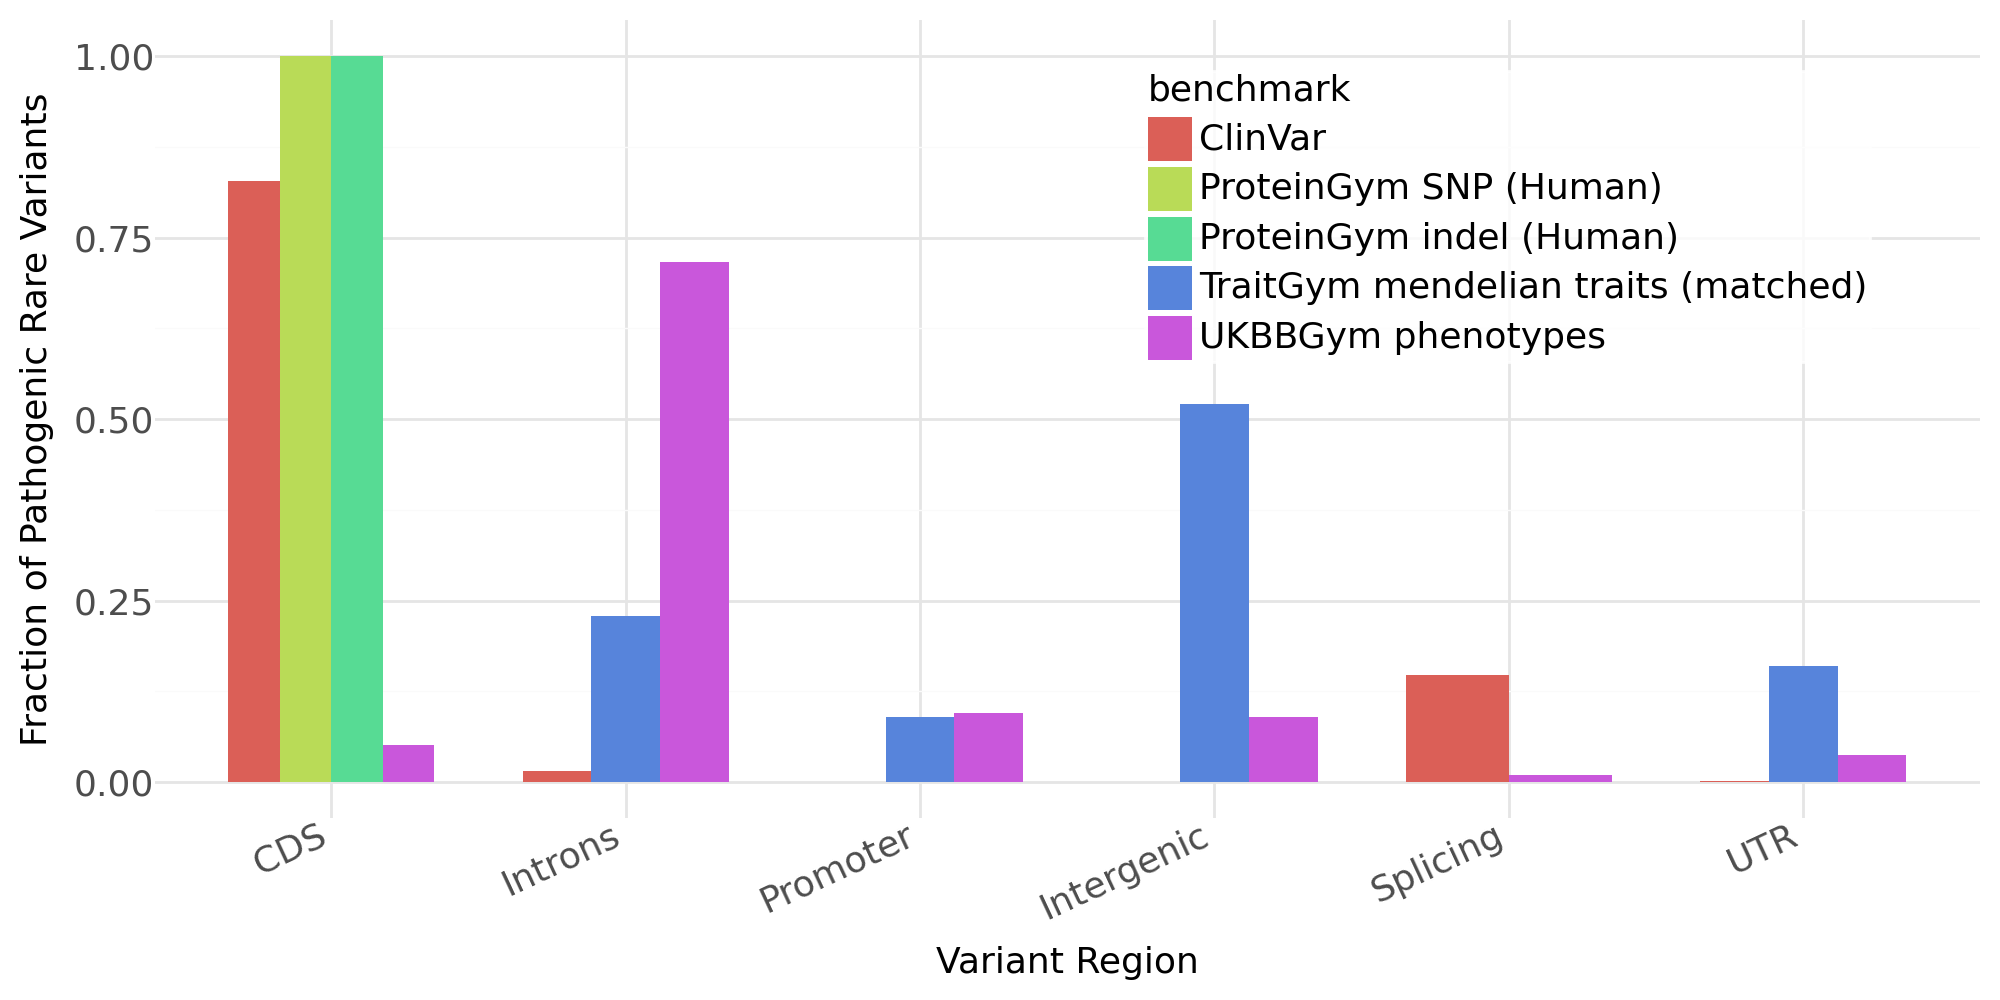

In [57]:
PLOT_TYPE = "fraction" 

if PLOT_TYPE == "fraction":
    y_col = "frac_patho_bmrk_region"
    y_label = "Fraction of Pathogenic Rare Variants"
else:
    y_col = "n_patho"
    y_label = "Pathogenic Rare Variants"

# --- Plotting ---
(
    ggplot(
        oth_bmrk_plot.filter(pl.col('benchmark')!="UKBBGym Olink")
    )
    + geom_bar(
        aes(
            # Sort x-axis by the y-value in descending order using reorder(cat, -val)
            x=f"reorder(broad_consequence, -{y_col})", 
            y=y_col,
            fill='benchmark'
        ),
        stat="identity",
        position="dodge",
        width=0.7,
    )
    + labs(
        x="Variant Region",
        y=y_label,
    )
    + theme_minimal()
    + theme(
        figure_size=(10, 5),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        axis_text_x=element_text(rotation=25, hjust=1), 
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        legend_position=(0.9, 0.9), 
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [ ]:
oth_bmrk_plot = (
    oth_bmrk
    .with_columns(
        n_variants = pl.len().over("benchmark"),
        n_pathogenic = pl.col("pathogenic").cast(pl.Int64).sum().over("benchmark")
    )
    .with_columns(
        n_variants_region = pl.len().over(["benchmark", "broad_consequence"]),
        n_pathogenic_region = pl.col("pathogenic").cast(pl.Int64).sum().over(["benchmark", "broad_consequence"])
    )
    .with_columns(
        frac_region = pl.col("n_variants_region") / pl.col("n_variants"),
        frac_of_pathogenic = pl.col("n_pathogenic") / pl.col("n_variants"),
        frac_of_pathogenic_in_region = pl.col("n_pathogenic_region") / pl.col("n_pathogenic"),
        frac_of_pathogenic_across_regions = pl.col("n_pathogenic_region") / pl.col("n_variants_region"),
    )
    .filter(pl.col("pathogenic").is_not_null())
    .drop(['id', 'pathogenic'])
    .unique()
)

oth_bmrk_plot

variant_region,benchmark,broad_consequence,n_variants,n_pathogenic,n_variants_region,n_pathogenic_region,frac_region,frac_of_pathogenic,frac_of_pathogenic_in_region,frac_of_pathogenic_across_regions
str,str,str,u64,i64,u64,i64,f64,f64,f64,f64
"""genic_upstream_transcript_vari…","""ClinVar""","""Promoter""",1503988,284520,504,54,0.000335,0.189177,0.00019,0.107143
"""5_prime_UTR_variant""","""TraitGym mendelian traits (mat…","""UTR""",14780,1478,2370,237,0.160352,0.1,0.160352,0.1
"""consequence_protein_altering_v…","""UKBBGym phenotypes""","""CDS""",27795365,535526,743772,25955,0.026759,0.019267,0.048466,0.034896
"""consequence_splice_acceptor_va…","""UKBBGym phenotypes""","""Splicing""",27795365,535526,126426,5041,0.004548,0.019267,0.009413,0.039873
"""consequence_start_lost""","""UKBBGym Olink""","""CDS""",16763475,18019,396330,6011,0.023642,0.001075,0.333592,0.015167
…,…,…,…,…,…,…,…,…,…,…
"""frameshift_variant""","""ProteinGym indel (Human)""","""CDS""",6944,190,6944,190,1.0,0.027362,1.0,0.027362
"""consequence_stop_gained""","""UKBBGym phenotypes""","""CDS""",27795365,535526,743772,25955,0.026759,0.019267,0.048466,0.034896
"""genic_downstream_transcript_va…","""ClinVar""","""Intergenic""",1503988,284520,624,102,0.000415,0.189177,0.000358,0.163462


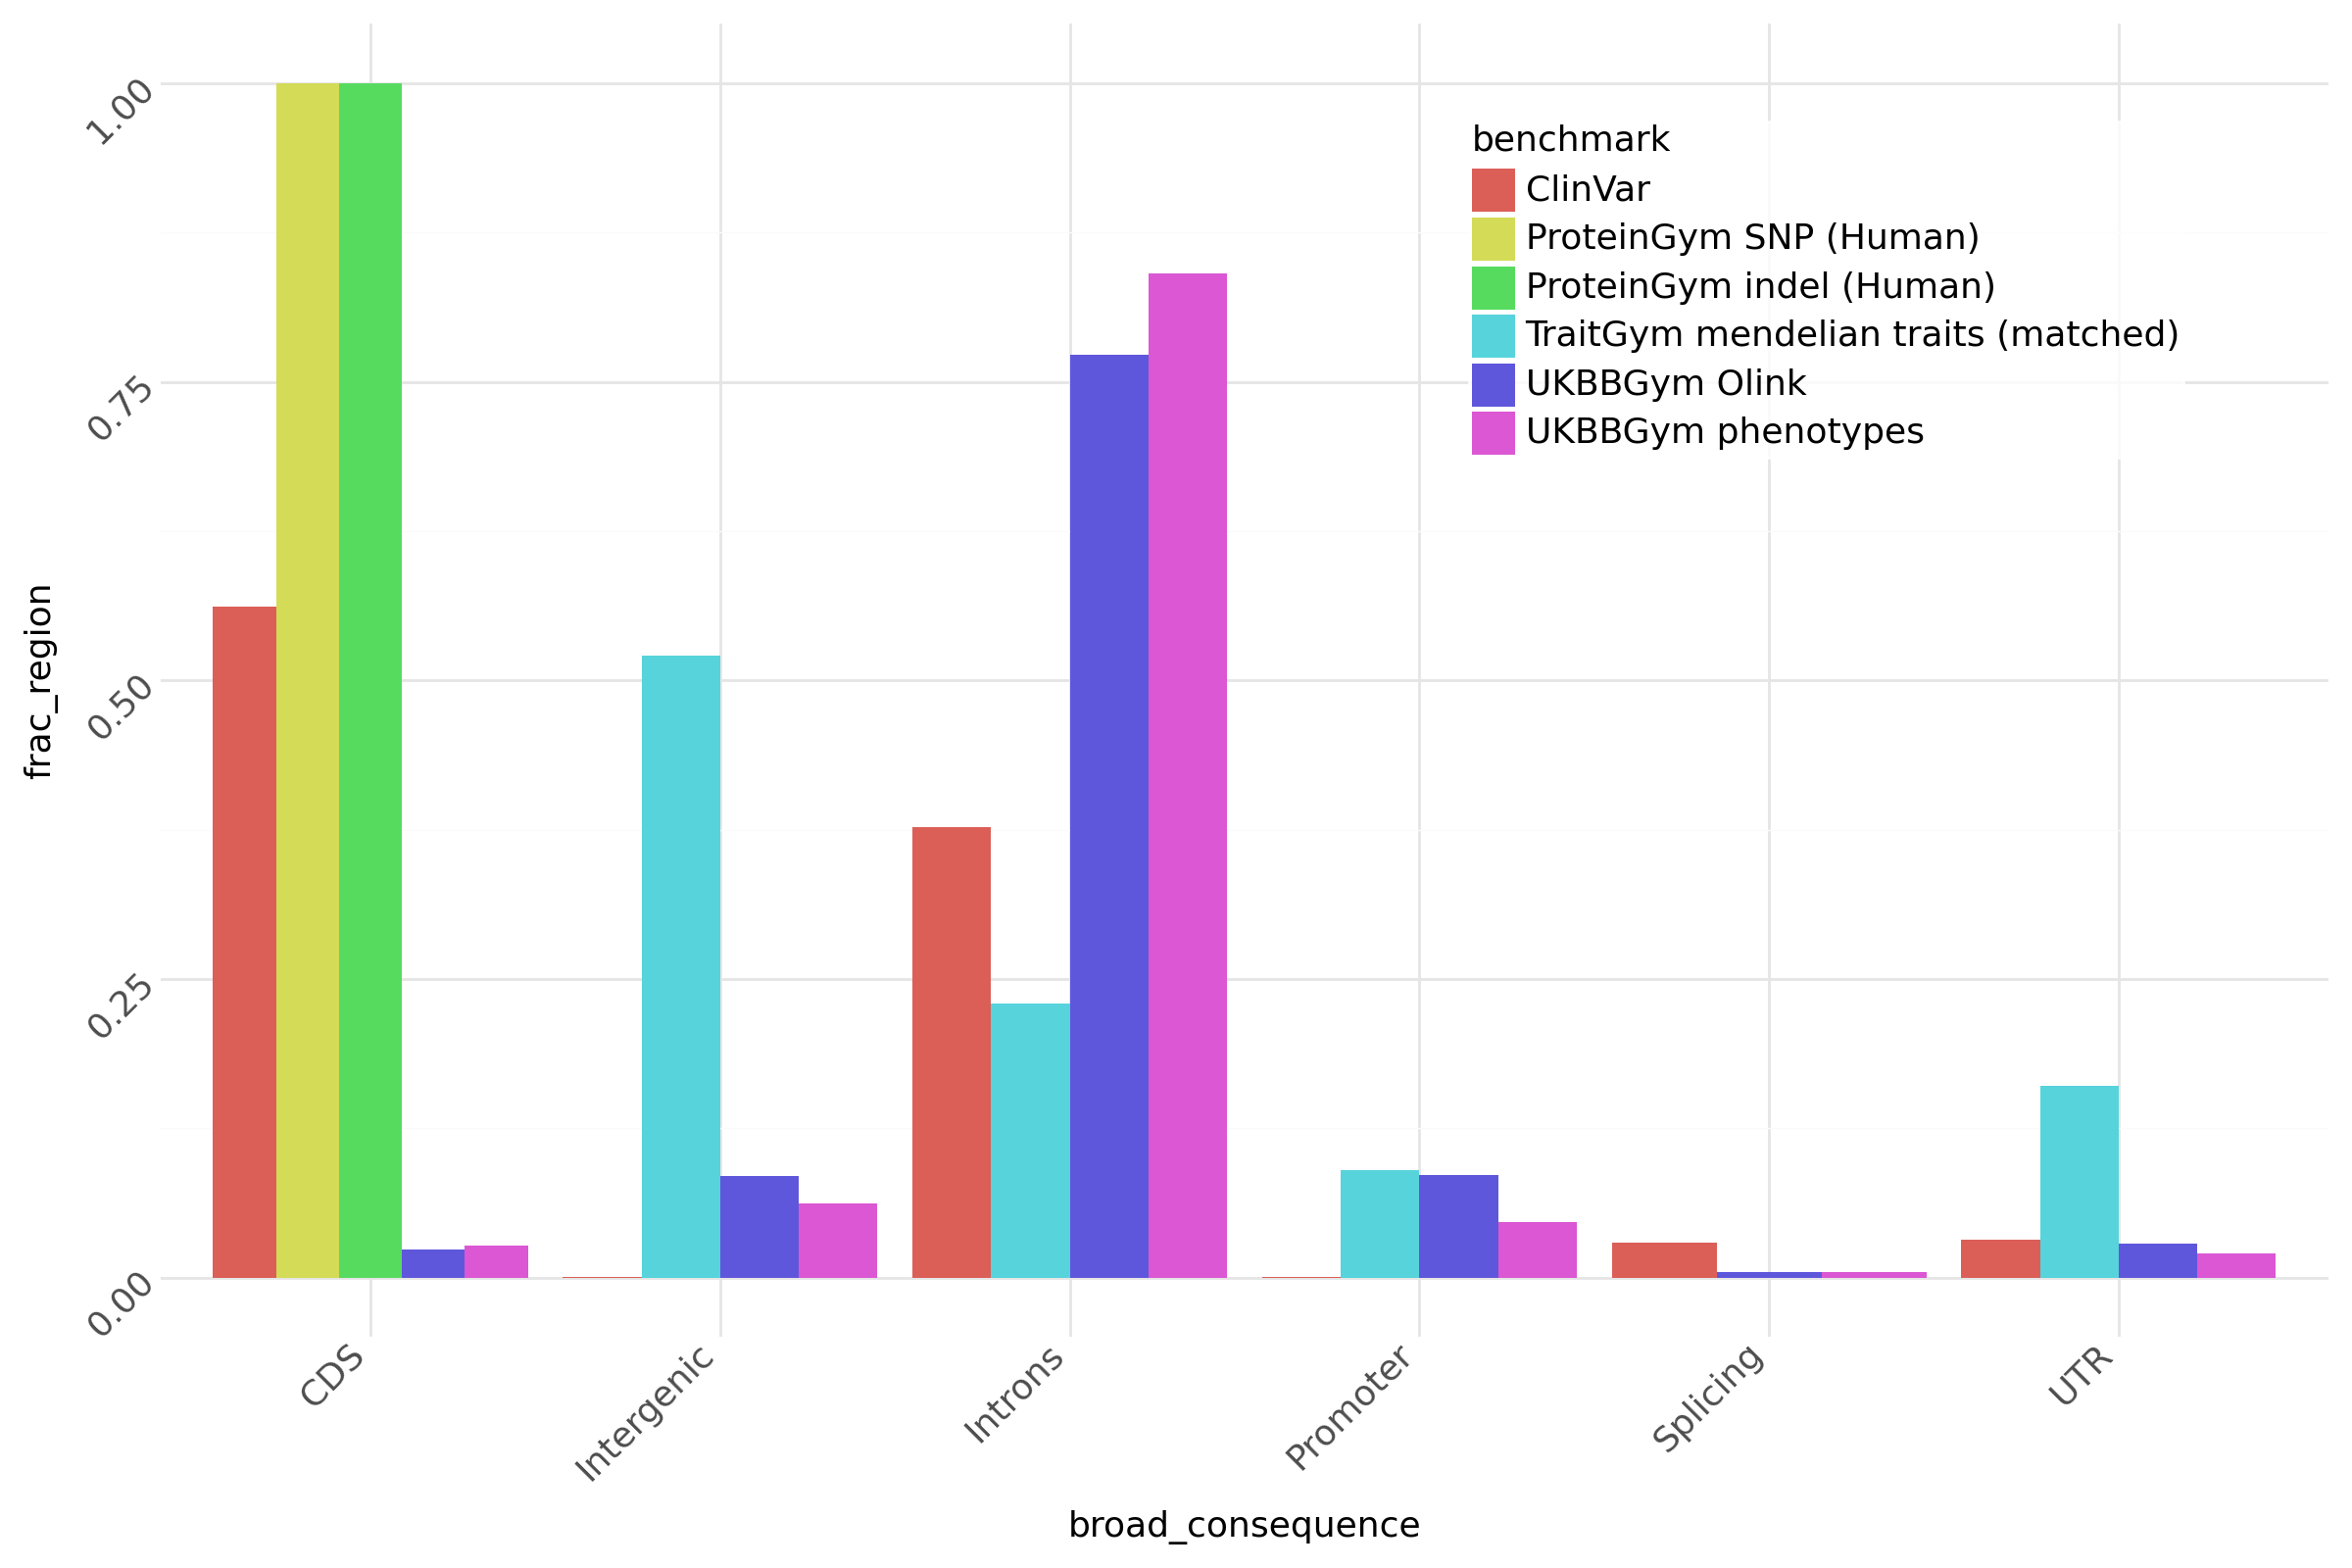

In [8]:
(
    ggplot(oth_bmrk_plot)
    + geom_bar(
        aes(x="broad_consequence", y="frac_region", fill="benchmark"),
        stat="identity",
        position="dodge"
    )
    + theme_minimal()
    + theme(
        figure_size=(12, 8),
        axis_text=element_text(size=13, angle=45, hjust=1),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        legend_position=(0.9, 0.9), 
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)

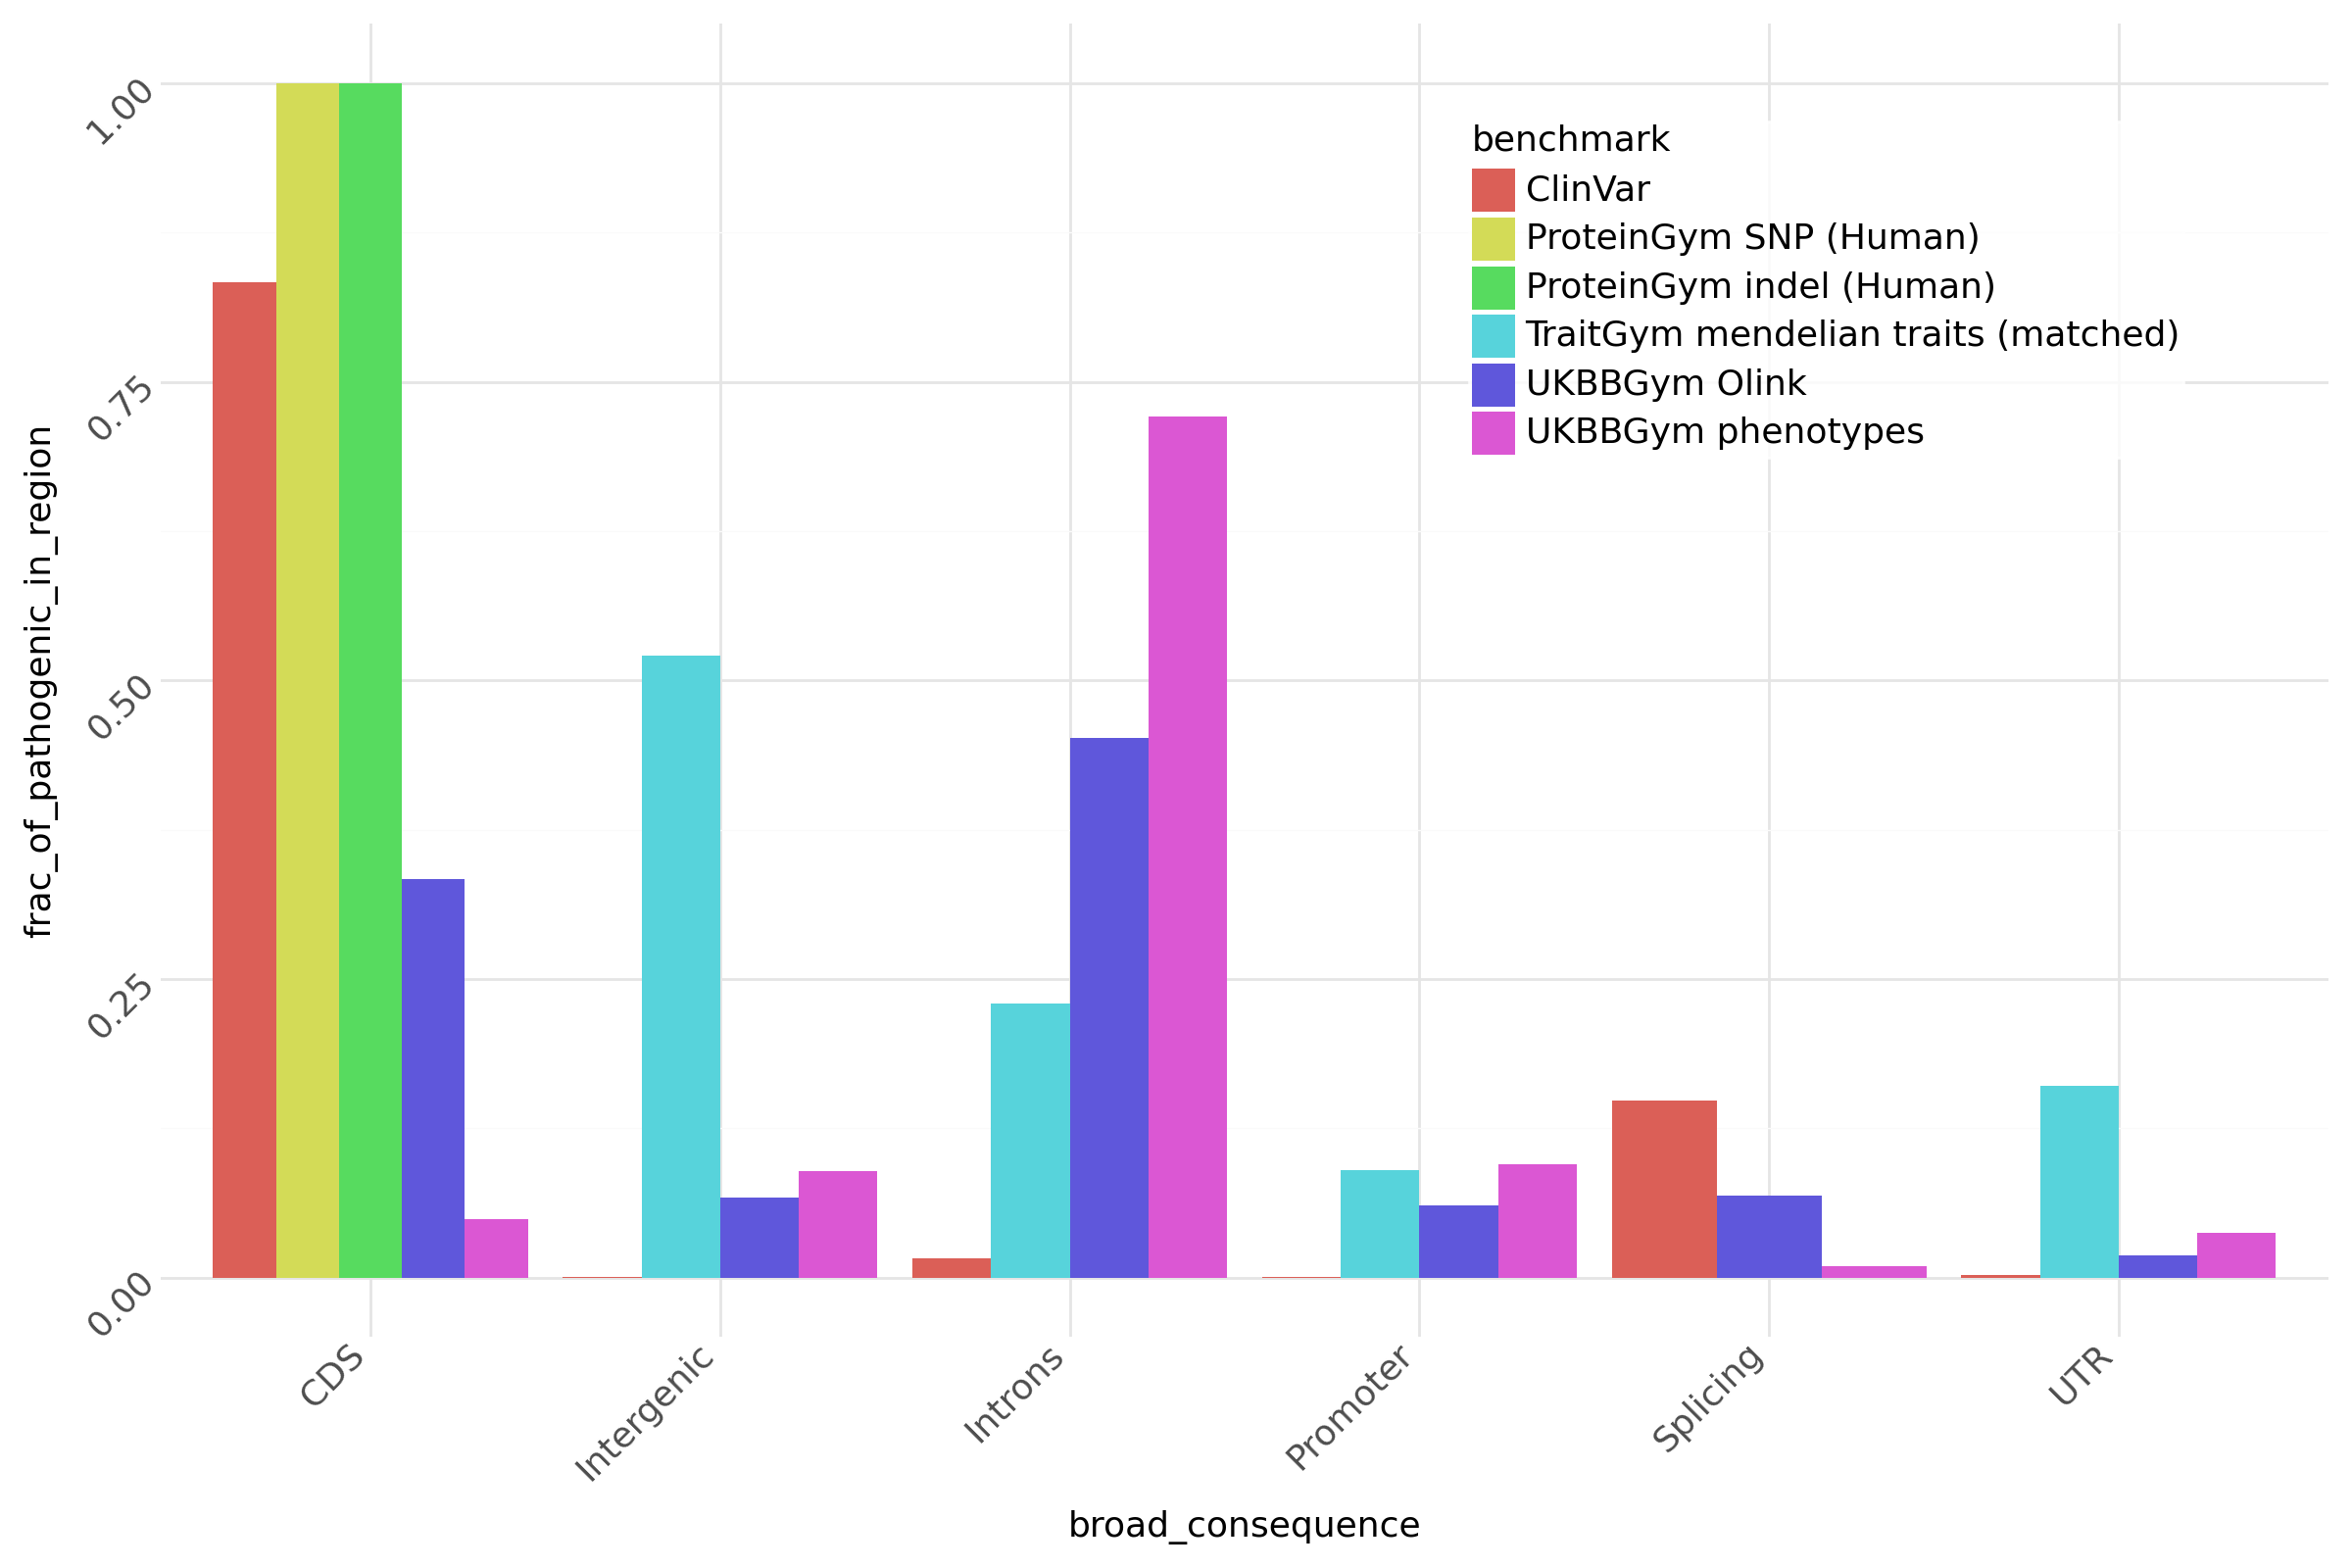

In [9]:
(
    ggplot(oth_bmrk_plot)
    + geom_bar(
        aes(x="broad_consequence", y="frac_of_pathogenic_in_region", fill="benchmark"),
        stat="identity",
        position="dodge"
    )
    + theme_minimal()
    + theme(
        figure_size=(12, 8),
        axis_text=element_text(size=13, angle=45, hjust=1),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        legend_position=(0.9, 0.9), 
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)

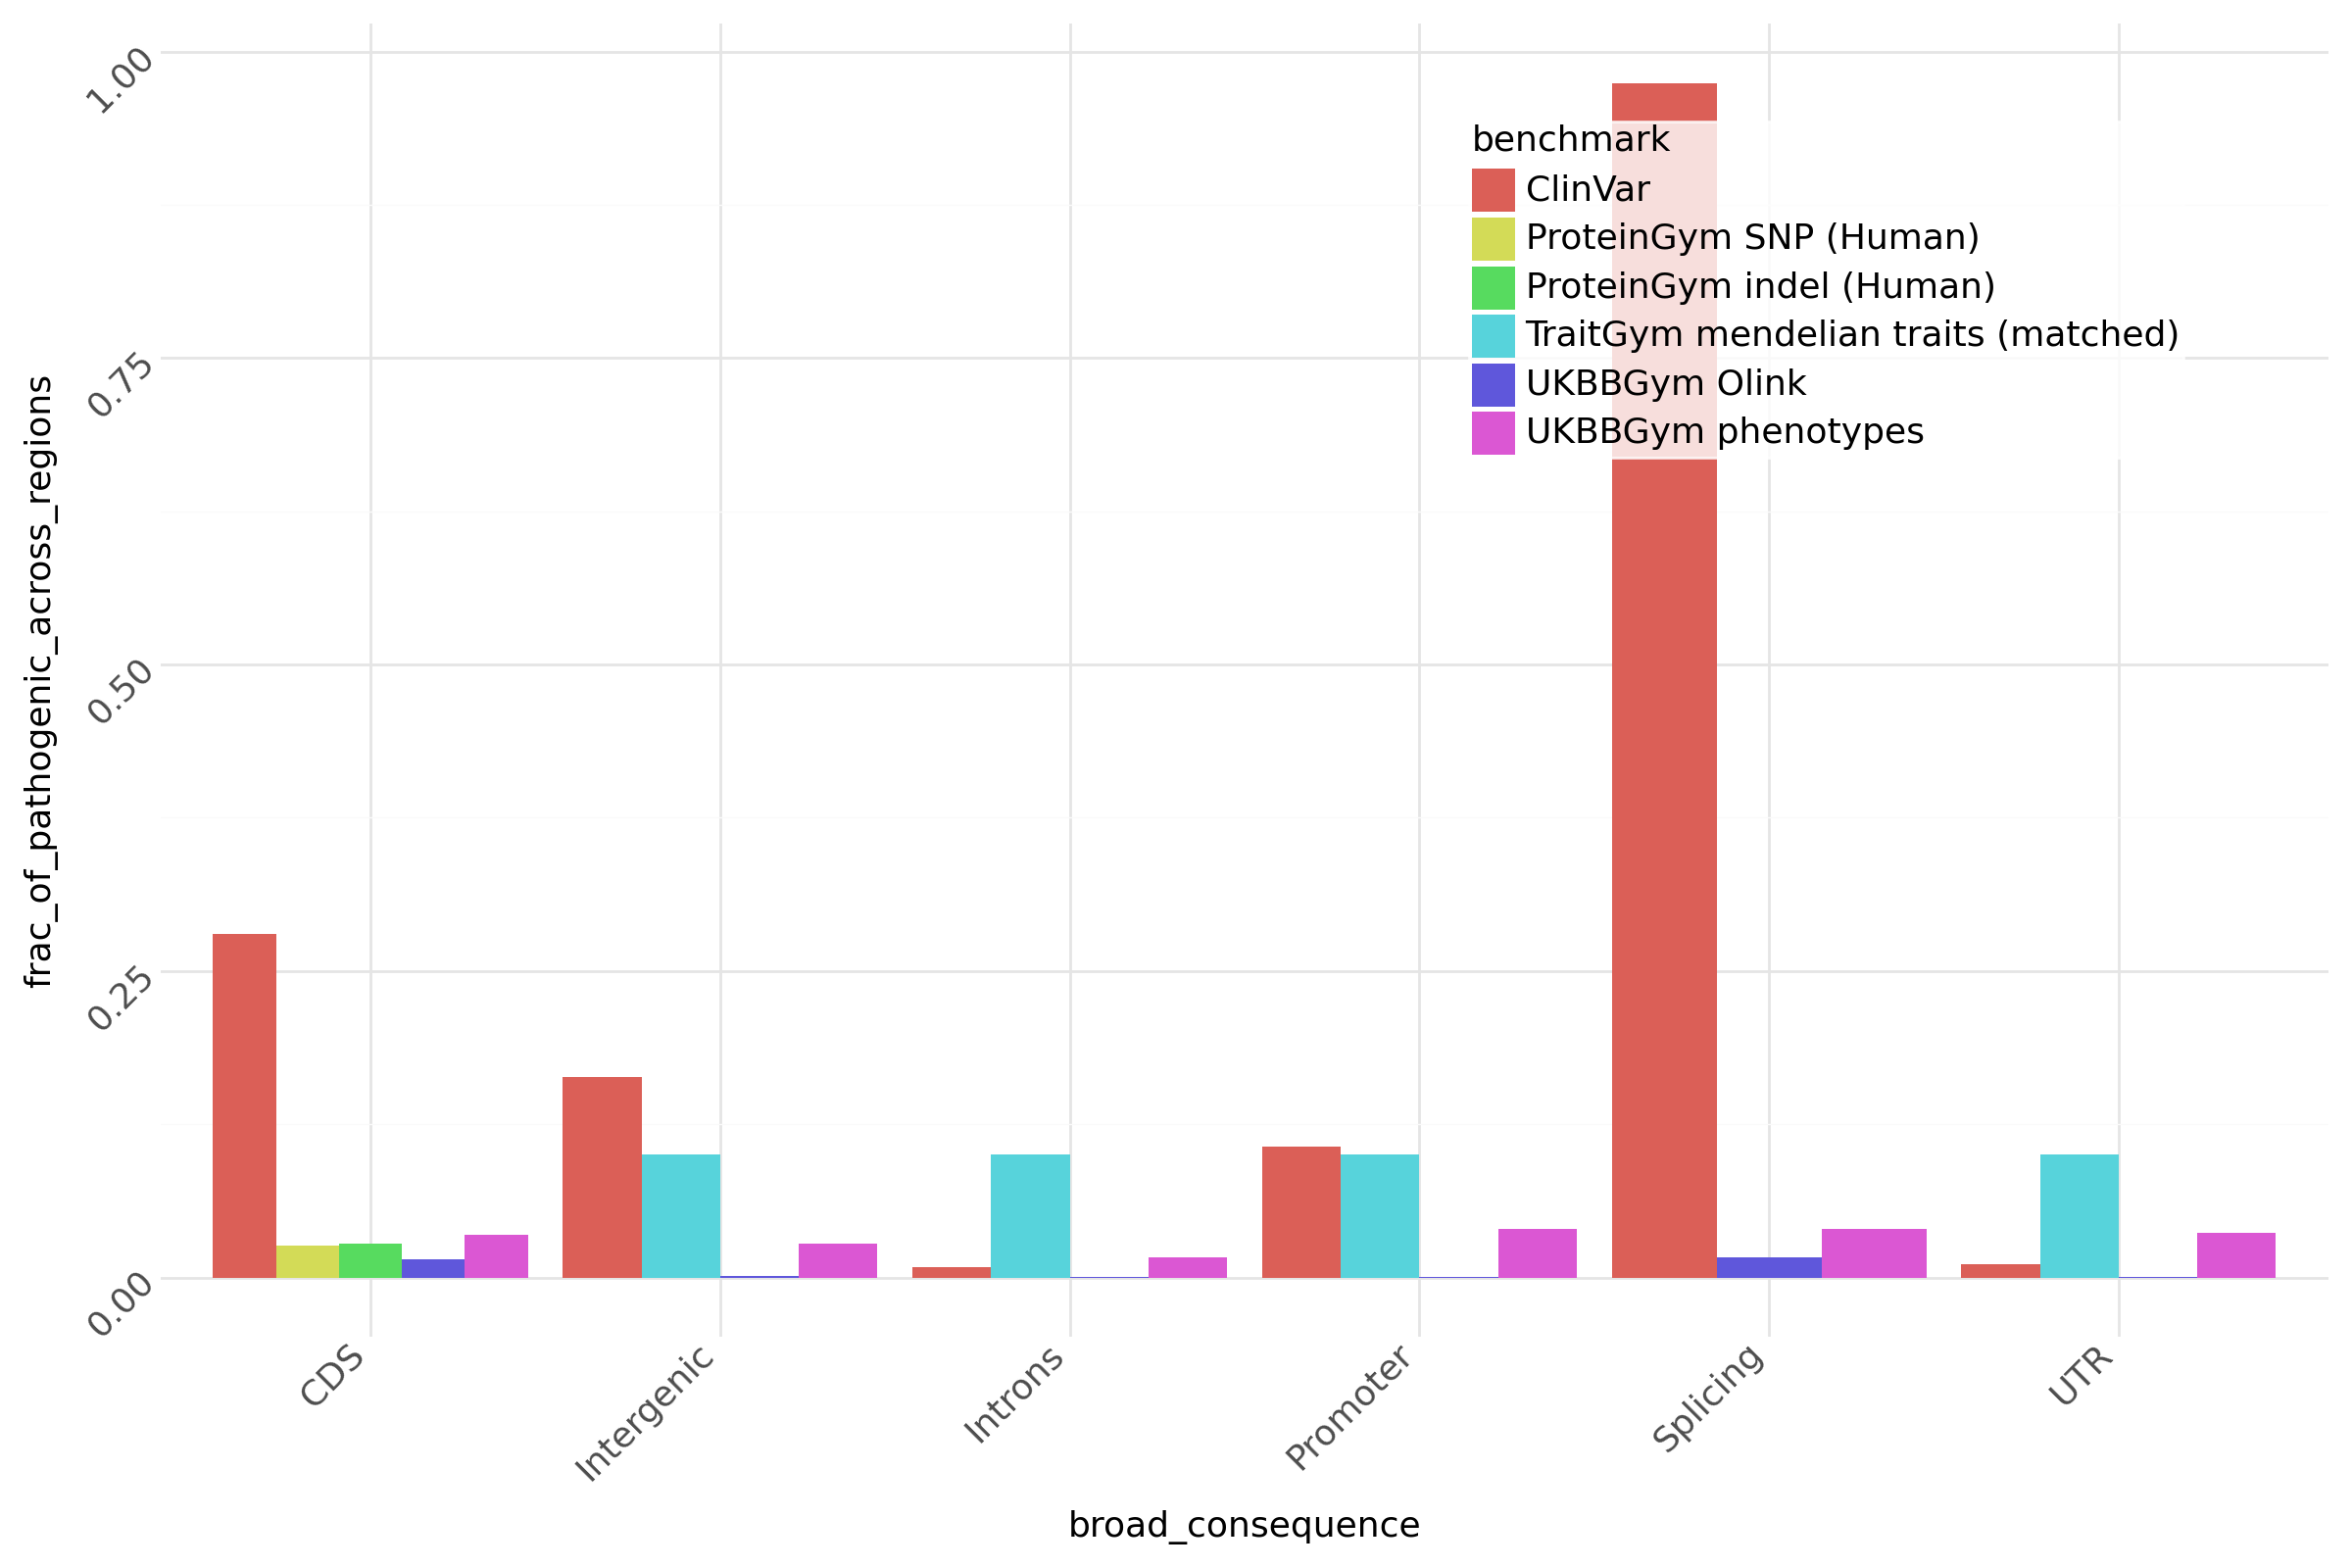

In [10]:
(
    ggplot(oth_bmrk_plot)
    + geom_bar(
        aes(x="broad_consequence", y="frac_of_pathogenic_across_regions", fill="benchmark"),
        stat="identity",
        position="dodge"
    )
    + theme_minimal()
    + theme(
        figure_size=(12, 8),
        axis_text=element_text(size=13, angle=45, hjust=1),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        legend_position=(0.9, 0.9), 
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)